Jorge Angon, Navpreet Kloy

#### Life Expectancy Dataset -- URL: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who


In [ ]:
# call the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
#load the data
df=pd.read_csv("Life Expectancy Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
# check for missing data values
print(df.isnull().sum())  # Counts the number of missing (NaN) values in each column
print(df.shape)  # Number of rows and columns



Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64
(2938, 22)


In [ ]:
# remove trailing spaces
print(df.columns.tolist())   # columns names before removal
df.columns = df.columns.str.strip()  #removes trailing spaces for all columns
print(df.columns.tolist())  # columns names after removal


['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population', ' thinness  1-19 years', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [ ]:
#remove the missing values with NaNs
df = df.dropna(subset=['Life expectancy','Schooling'])
print(df.shape) #confirm shape after dropping

(2768, 22)


Text(0, 0.5, 'Schooling (yr)')

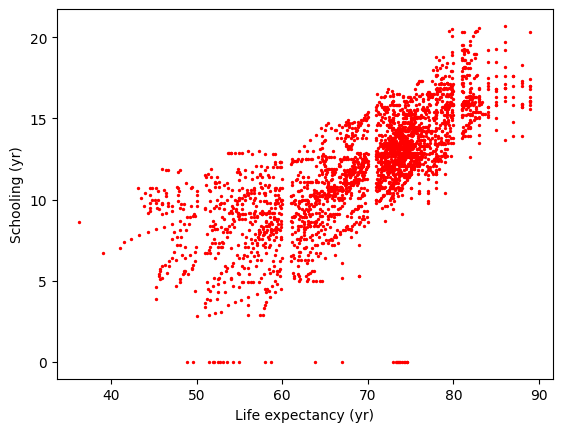

In [ ]:
# plot scatterplot for data points
plt.scatter(df['Life expectancy'],df['Schooling'], c='red', s=2) #plots each data point with specified color and size
plt.xlabel("Life expectancy (yr)") #set label for x-axis
plt.ylabel("Schooling (yr)")  #set label for y-axis

In [ ]:
#K-mean clustering
k=4   #set number of clusters
X=np.array(list(zip(df['Life expectancy'], df['Schooling'])))  #create a matrix of the specified data points
model=KMeans(n_clusters=k)   # initialize KMeans
kmeans=model.fit(X)   #train model with the data points
labels=model.predict(X) #assign each data point to a label (cluster)
centroids=model.cluster_centers_  #get cluster centriods

print(labels)   #print assigned cluster label for each data point
print(centroids) #print centriods of each cluster

[2 2 2 ... 1 1 1]
[[73.62933921 13.0045815 ]
 [53.455       7.99458333]
 [64.94635258 10.20881459]
 [80.80242424 15.95959596]]


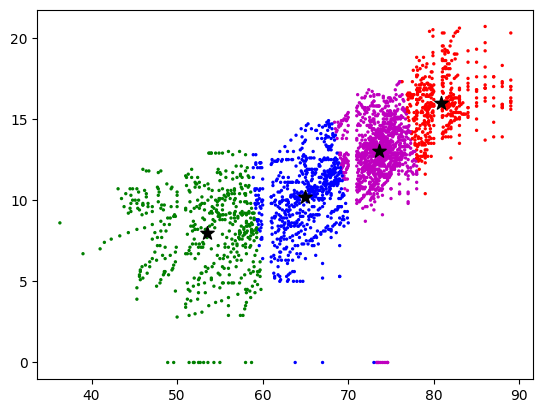

In [ ]:
#Plot the data and centroids on a scatter plot
#map the labels to colors

c=['m','g','b','r','y','c']  #define a list of colors for clusters
colors=[c[i] for i in labels]   #color assigned for each data point based on its label

plt.scatter(df['Life expectancy'], df['Schooling'], c=colors, s=2)  #plots each data point
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=100, c='black') #plot the cluster centriods

In [ ]:
#To determine the silhouette coefficient/score

from sklearn.metrics import silhouette_score

model=KMeans(n_clusters=2)  #initialize KMeans model with 2 clusters
model.fit(X)  #train model
label=model.predict(X) #assign each data point to a label (cluster)

print(f'silhouette Score (n=2): {silhouette_score(X,label)}')


model=KMeans(n_clusters=3)  #clustering for k=3
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=3): {silhouette_score(X,label)}')


model=KMeans(n_clusters=4)  #clustering for k=4
model.fit(X)
label=model.predict(X)

print(f'silhouette Score (n=4): {silhouette_score(X,label)}')

silhouette Score (n=2): 0.5928718740917299
silhouette Score (n=3): 0.43163080618264643
silhouette Score (n=4): 0.48250205587972217


Silhouette coefficient/score: The optimal k-value is 2 as the silhouette coefficient/score is closer to 1. However, k-value 4 was chosen to help analyze more groups and observe trends. The silhouette coefficient/score for k-value of 4 was 0.48.  


**Summary:**The data set contains factors that are related to life expectancy from 193 different countries from the years 2000 to 2015. The factors range from immunizations, social factors such as schooling and alcohol, economical factors, mortality factors, population, and various other health factors. For this collection , life expectancy and schooling were chosen. Schooling is the number of years of education and life expectancy is the expected age. All countries and years dataset were used, totalling 2768 datapoints. K-means clustering algorithm was used to group data points and identify patterns. A  k-value of 4 was used, meaning the data was grouped into four similar categories. The results show that countries with higher education tend to have greater life expectancy. Across the 4 groups, there was a difference of 10 years in life expectancy. On the higher end, one group had an average of 15 years of schooling with a life expectancy of around 80. The group with lowest average schooling of 7 years had an average life expectancy of 53. Overall, the results show there is an upward trend in life expectancy with increased amount of schooling.
